# Enhanced Deepfake Detection System

## Improvements in this notebook:
1. **Face Detection Preprocessing** - Extract and align faces before classification
2. **Enhanced CNN Architecture** - Attention mechanisms + Residual connections
3. **Comprehensive Evaluation** - Multiple metrics, ROC curves, PR curves
4. **Grad-CAM Visualization** - See what the model focuses on
5. **Better Data Augmentation** - More robust training
6. **Cross-validation** - More reliable performance estimates

---

In [ ]:
!pip install -q kaggle


In [ ]:
from google.colab import files
files.upload()   

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"elboumashouliachraf","key":"4f57f35dae4ea2a8f6bda5ca6d712b35"}'}

In [ ]:
!mkdir -p /root/.config/kaggle
!mv kaggle.json /root/.config/kaggle/
!chmod 600 /root/.config/kaggle/kaggle.json

In [ ]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

api.dataset_download_files(
    'manjilkarki/deepfake-and-real-images',
    path= "/content/deep-fake-detection",
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images


In [ ]:
!ls /content/deep-fake-detection


Dataset


## 1. Imports and Setup

In [ ]:
!pip install tensorflow opencv-python

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
import cv2
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    TensorBoard
)
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [ ]:
class Config:
    """Enhanced configuration with Drive support"""

    # Base directory in Google Drive
    BASE_DIR = "/content/deep-fake-detection"

    # Dataset paths
    DATASET_PATH = os.path.join(BASE_DIR, "Dataset")
    TRAIN_DIR = os.path.join(DATASET_PATH, "Train")
    VAL_DIR = os.path.join(DATASET_PATH, "Validation")
    TEST_DIR = os.path.join(DATASET_PATH, "Test")

    # Model directory with timestamp (saved to Drive)
    TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
    MODEL_DIR = os.path.join(BASE_DIR, f"models_{TIMESTAMP}")
    os.makedirs(MODEL_DIR, exist_ok=True)

    # Image parameters
    IMG_HEIGHT = 128
    IMG_WIDTH = 128
    IMG_CHANNELS = 3            RGB
    IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

    # Training parameters
    BATCH_SIZE = 32
    EPOCHS = 11
    INITIAL_LR = 0.001

    # Class names
    CLASS_NAMES = ['Fake', 'Real']

    # Model save paths
    MODEL_PATH = os.path.join(MODEL_DIR, "deepfake_enhanced_model.keras")
    MODEL_PATH_H5 = os.path.join(MODEL_DIR, "deepfake_enhanced_model.h5")
    BEST_MODEL_PATH = os.path.join(MODEL_DIR, "best_model.keras")


    # Face detection (Haar Cascade)
    FACE_CASCADE_PATH = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"

config = Config()
print(f" Configuration loaded")
print(f" Datas
et path: {config.DATASET_PATH}")
print(f" Model directory: {config.MODEL_DIR}")

✅ Configuration loaded
📂 Dataset path: /content/deep-fake-detection/Dataset
💾 Model directory: /content/deep-fake-detection/models_20260216_221819


## 3. Face Detection Preprocessing

In [ ]:
class FaceDetector:
    """Face detection and preprocessing utility"""

    def __init__(self):
        self.face_cascade = cv2.CascadeClassifier(config.FACE_CASCADE_PATH)
        if self.face_cascade.empty():
            print("Warning: Could not load face cascade. Will use full images.")
            self.face_cascade = None

    def detect_and_extract_face(self, img_path, return_original=False):
       
        # Read image
        img = cv2.imread(img_path)
        if img is None:
            return None

        # Convert to RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # If face cascade not available, return resized image
        if self.face_cascade is None:
            resized = cv2.resize(img_rgb, (config.IMG_WIDTH, config.IMG_HEIGHT))
            return resized / 255.0

        # Detect faces
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = self.face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(30, 30)
        )

        # If faces detected, extract largest one
        if len(faces) > 0:
            # Get largest face
            largest_face = max(faces, key=lambda rect: rect[2] * rect[3])
            x, y, w, h = largest_face

            # Add margin
            margin = int(0.2 * max(w, h))
            x = max(0, x - margin)
            y = max(0, y - margin)
            w = min(img_rgb.shape[1] - x, w + 2 * margin)
            h = min(img_rgb.shape[0] - y, h + 2 * margin)

            # Extract and resize face
            face_img = img_rgb[y:y+h, x:x+w]
            face_resized = cv2.resize(face_img, (config.IMG_WIDTH, config.IMG_HEIGHT))

            return face_resized / 255.0
        else:
            # No face detected, use full image
            resized = cv2.resize(img_rgb, (config.IMG_WIDTH, config.IMG_HEIGHT))
            return resized / 255.0

    def visualize_detection(self, img_path):
     
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        if self.face_cascade is not None:
            faces = self.face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(30, 30))

            for (x, y, w, h) in faces:
                cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (255, 0, 0), 2)

        plt.figure(figsize=(10, 6))
        plt.imshow(img_rgb)
        plt.title(f"Detected {len(faces) if self.face_cascade else 0} face(s)")
        plt.axis('off')
        plt.show()

# Initialize face detector
face_detector = FaceDetector()
print("Face detector initialized")

Face detector initialized


### Test Face Detection

Testing on: /content/deep-fake-detection/Dataset/Train/Real/real_35552.jpg


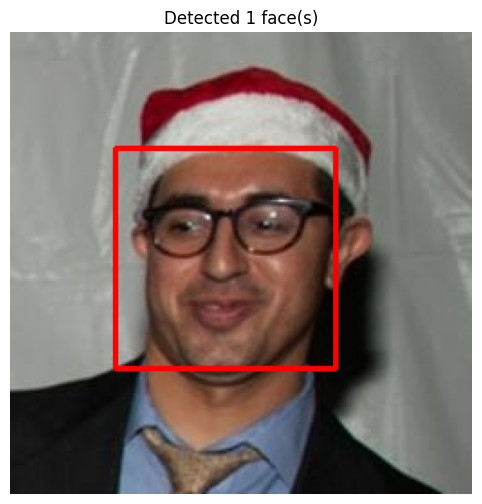

In [ ]:
# Test on a sample image
sample_real = os.path.join(config.TRAIN_DIR, "Real")
sample_fake = os.path.join(config.TRAIN_DIR, "Fake")

if os.path.exists(sample_real):
    sample_img = os.path.join(sample_real, os.listdir(sample_real)[5])
    print(f"Testing on: {sample_img}")
    face_detector.visualize_detection(sample_img)

## 4. Enhanced Data Loading with Augmentation

In [ ]:
def create_enhanced_generators():

    # Enhanced training augmentation
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        zoom_range=0.15,
        shear_range=0.1,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest'
    )

    # Validation and test: only rescaling
    val_test_datagen = ImageDataGenerator(rescale=1./255)

    # Create generators
    train_gen = train_datagen.flow_from_directory(
        config.TRAIN_DIR,
        target_size=(config.IMG_HEIGHT, config.IMG_WIDTH),
        batch_size=config.BATCH_SIZE,
        class_mode='binary',
        shuffle=True,
        seed=42
    )

    val_gen = val_test_datagen.flow_from_directory(
        config.VAL_DIR,
        target_size=(config.IMG_HEIGHT, config.IMG_WIDTH),
        batch_size=config.BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )

    test_gen = val_test_datagen.flow_from_directory(
        config.TEST_DIR,
        target_size=(config.IMG_HEIGHT, config.IMG_WIDTH),
        batch_size=config.BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )

    print(f"Training samples: {train_gen.samples}")
    print(f"Validation samples: {val_gen.samples}")
    print(f"Test samples: {test_gen.samples}")
    print(f"Class indices: {train_gen.class_indices}")

    return train_gen, val_gen, test_gen

# Load data
print("Loading data...")
train_gen, val_gen, test_gen = create_enhanced_generators()

Loading data...
Found 140002 images belonging to 2 classes.
Found 39428 images belonging to 2 classes.
Found 10905 images belonging to 2 classes.
Training samples: 140002
Validation samples: 39428
Test samples: 10905
Class indices: {'Fake': 0, 'Real': 1}


### Visualize Sample Data

Sample training images:


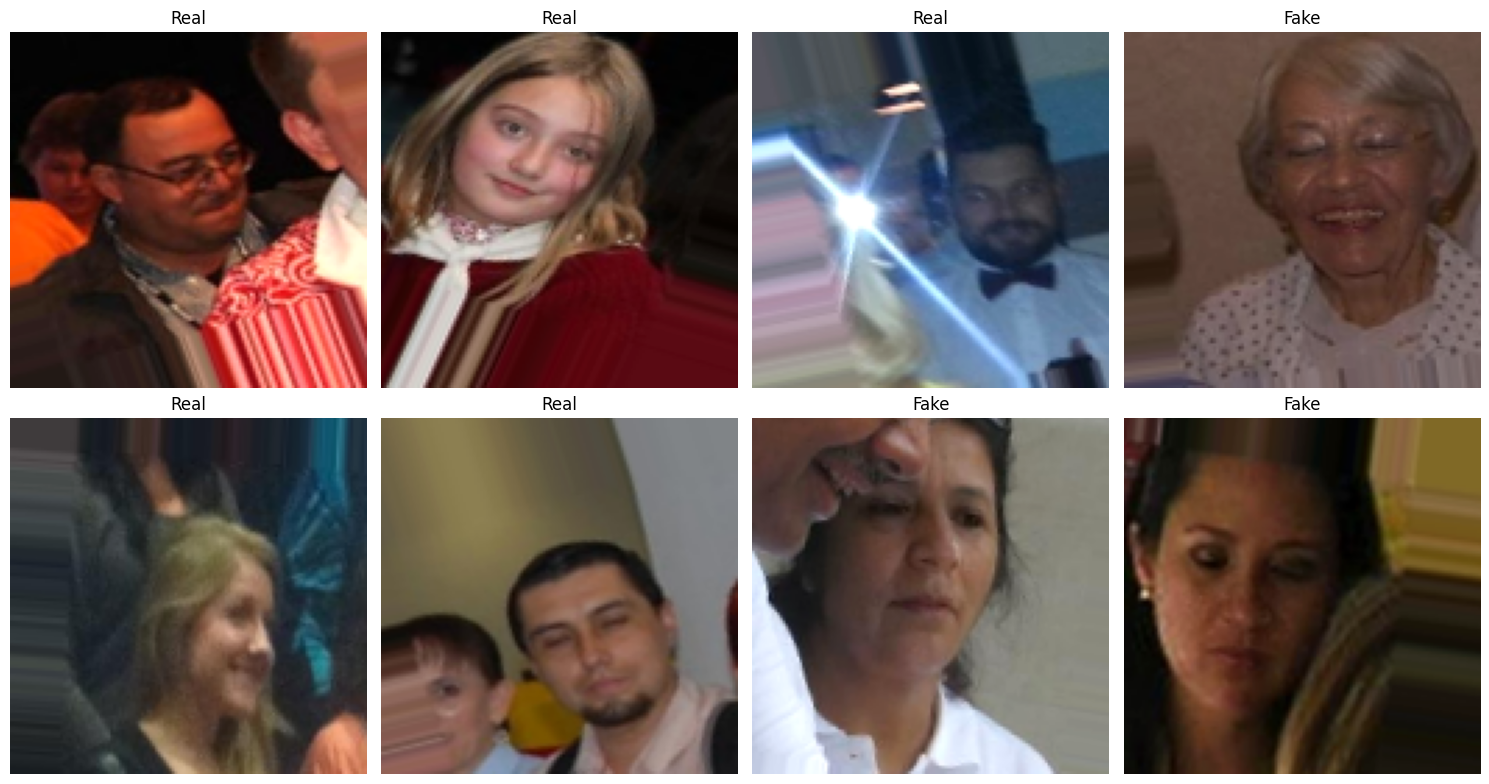

In [ ]:
def visualize_samples(generator, num_samples=8):
    """Visualize sample images from generator"""
    x_batch, y_batch = next(generator)

    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    axes = axes.ravel()

    for i in range(min(num_samples, len(x_batch))):
        axes[i].imshow(x_batch[i])
        label = "Real" if y_batch[i] == 1 else "Fake"
        axes[i].set_title(f"{label}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(config.MODEL_DIR, 'sample_images.png'), dpi=150)
    plt.show()

print("Sample training images:")
visualize_samples(train_gen)

## 5. Enhanced Model Architecture with Attention

In [ ]:
def channel_attention_block(input_tensor, reduction_ratio=8):
   
    channels = input_tensor.shape[-1]

    # Global average pooling
    avg_pool = layers.GlobalAveragePooling2D()(input_tensor)

    # MLP
    dense1 = layers.Dense(channels // reduction_ratio, activation='relu')(avg_pool)
    dense2 = layers.Dense(channels, activation='sigmoid')(dense1)

    # Reshape and multiply
    attention = layers.Reshape((1, 1, channels))(dense2)
    output = layers.Multiply()([input_tensor, attention])

    return output

def residual_block(x, filters, use_attention=True):
    
    shortcut = x

    # First conv
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Second conv
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Attention
    if use_attention:
        x = channel_attention_block(x)

    # Shortcut connection
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

In [ ]:
def build_enhanced_model():
   

    inputs = layers.Input(shape=config.IMG_SHAPE)

    # Initial convolution
    x = layers.Conv2D(32, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Residual blocks with increasing filters
    for filters in [64, 128, 256]:
        x = residual_block(x, filters, use_attention=True)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Dropout(0.25)(x)

    # Global pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Dense layers
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    # Output layer
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs, name='DeepfakeDetector_Enhanced')

    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config.INITIAL_LR),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')
        ]
    )

    return model

# Build model
print("Building enhanced model...")
model = build_enhanced_model()
model.summary()

# Save model architecture
keras.utils.plot_model(
    model,
    to_file=os.path.join(config.MODEL_DIR, 'model_architecture.png'),
    show_shapes=True,
    show_layer_names=True
)
print(f"\nTotal parameters: {model.count_params():,}")

Building enhanced model...


Model: "DeepfakeDetector_Enhanced"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     18,496 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        576 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      2,112 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ multiply[0][0],   │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ add[0][0]       

 Total params: 1,497,145 (5.71 MB)

 Trainable params: 1,494,393 (5.70 MB)

 Non-trainable params: 2,752 (10.75 KB)


Total parameters: 1,497,145


## 6. Training Callbacks

In [ ]:
# Create callbacks
callbacks = [
   
    ModelCheckpoint(
        config.BEST_MODEL_PATH,
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

   
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),

    TensorBoard(
        log_dir=os.path.join(config.MODEL_DIR, 'logs'),
        histogram_freq=1
    )
]

print("Callbacks configured")

Callbacks configured


## 7. Model Training

In [ ]:
print("Starting training...")
print(f"Batch size: {config.BATCH_SIZE}")
print(f"Epochs: {config.EPOCHS}")
print(f"Initial learning rate: {config.INITIAL_LR}")
print("-" * 60)

history = model.fit(
    train_gen,
    epochs=config.EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")

Starting training...
Batch size: 32
Epochs: 11
Initial learning rate: 0.001
------------------------------------------------------------
Epoch 1/11
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.6349 - auc: 0.6878 - loss: 0.6249 - precision: 0.6231 - recall: 0.6789
Epoch 1: val_auc improved from -inf to 0.91116, saving model to /content/deep-fake-detection/models_20260216_221819/best_model.keras
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 1075s 238ms/step - accuracy: 0.6349 - auc: 0.6879 - loss: 0.6249 - precision: 0.6231 - recall: 0.6790 - val_accuracy: 0.8108 - val_auc: 0.9112 - val_loss: 0.4308 - val_precision: 0.8614 - val_recall: 0.7425 - learning_rate: 0.0010
Epoch 2/11
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8946 - auc: 0.9614 - loss: 0.2517 - precision: 0.8967 - recall: 0.8910
Epoch 2: val_auc improved from 0.91116 to 0.95206, saving model to /content/deep-fake-detection/models_20260216_221819/best_model.keras
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 1013s 231ms/step - 

In [ ]:
# Save final model
model.save(config.MODEL_PATH)
model.save(config.MODEL_PATH_H5)
print(f"Model saved to: {config.MODEL_PATH}")
print(f"Model saved to: {config.MODEL_PATH_H5}")

Model saved to: /content/deep-fake-detection/models_20260216_221819/deepfake_enhanced_model.keras
Model saved to: /content/deep-fake-detection/models_20260216_221819/deepfake_enhanced_model.h5


## 8. Training Visualization

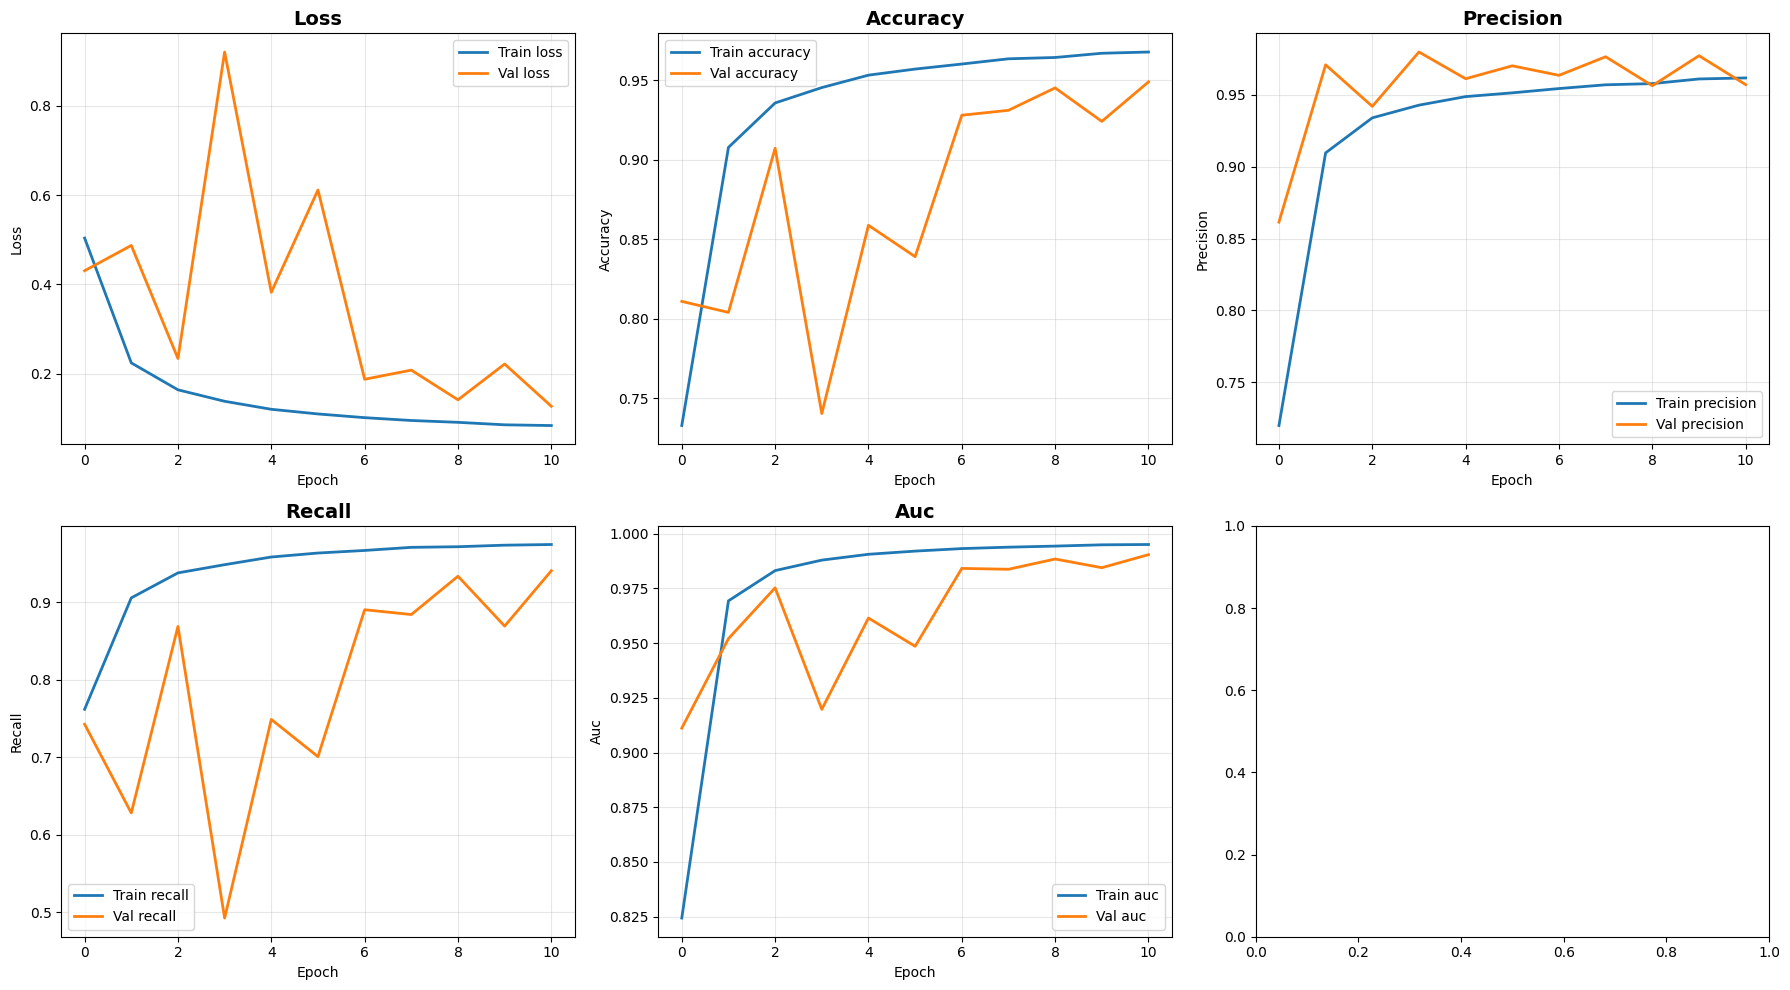

In [ ]:
def plot_training_history(history):

    metrics = ['loss', 'accuracy', 'precision', 'recall', 'auc']
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, metric in enumerate(metrics):
        axes[i].plot(history.history[metric], label=f'Train {metric}', linewidth=2)
        axes[i].plot(history.history[f'val_{metric}'], label=f'Val {metric}', linewidth=2)
        axes[i].set_title(f'{metric.capitalize()}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Epoch')
        axes[i].set_ylabel(metric.capitalize())
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

    # Learning rate plot if available
    if 'lr' in history.history:
        axes[5].plot(history.history['lr'], linewidth=2, color='red')
        axes[5].set_title('Learning Rate', fontsize=14, fontweight='bold')
        axes[5].set_xlabel('Epoch')
        axes[5].set_ylabel('LR')
        axes[5].set_yscale('log')
        axes[5].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(config.MODEL_DIR, 'training_history.png'), dpi=150)
    plt.show()

plot_training_history(history)

## 9. Comprehensive Evaluation

In [ ]:
def comprehensive_evaluation(model, test_gen):


    print("Evaluating model on test set...")
    print("=" * 60)

    # Get predictions
    test_gen.reset()
    predictions = model.predict(test_gen, verbose=1)
    y_pred_prob = predictions.flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)
    y_true = test_gen.classes[:len(predictions)]

    # Basic metrics
    test_loss, test_acc, test_precision, test_recall, test_auc = model.evaluate(
        test_gen,
        verbose=0
    )

    print(f"\nTest Metrics:")
    print(f"  Loss: {test_loss:.4f}")
    print(f"  Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"  Precision: {test_precision:.4f}")
    print(f"  Recall: {test_recall:.4f}")
    print(f"  AUC: {test_auc:.4f}")


    cm = confusion_matrix(y_true, y_pred)

   
    print("\n" + "=" * 60)
    print("Classification Report:")
    print("=" * 60)
    print(classification_report(
        y_true,
        y_pred,
        target_names=config.CLASS_NAMES,
        digits=4
    ))

    
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_pred_prob)
    avg_precision = average_precision_score(y_true, y_pred_prob)

    return {
        'y_true': y_true,
        'y_pred': y_pred,
        'y_pred_prob': y_pred_prob,
        'confusion_matrix': cm,
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc,
        'precision': precision,
        'recall': recall,
        'avg_precision': avg_precision,
        'metrics': {
            'loss': test_loss,
            'accuracy': test_acc,
            'precision': test_precision,
            'recall': test_recall,
            'auc': test_auc
        }
    }


eval_results = comprehensive_evaluation(model, test_gen)

Evaluating model on test set...
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step

Test Metrics:
  Loss: 0.4119
  Accuracy: 0.8548 (85.48%)
  Precision: 0.9325
  Recall: 0.7628
  AUC: 0.9452

Classification Report:
              precision    recall  f1-score   support

        Fake     0.8018    0.9456    0.8677      5492
        Real     0.9325    0.7628    0.8391      5413

    accuracy                         0.8548     10905
   macro avg     0.8671    0.8542    0.8534     10905
weighted avg     0.8666    0.8548    0.8535     10905



## 10. Evaluation Visualizations

In [ ]:
def plot_confusion_matrix(cm, class_names):
   

    plt.figure(figsize=(10, 8))

    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Create annotations
    annotations = np.array([[f'{count}\n({percent:.1%})'
                            for count, percent in zip(row_counts, row_percents)]
                           for row_counts, row_percents in zip(cm, cm_normalized)])

    sns.heatmap(
        cm_normalized,
        annot=annotations,
        fmt='',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Percentage'},
        square=True
    )

    plt.title('Confusion Matrix\n(Count and Percentage)',
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(config.MODEL_DIR, 'confusion_matrix.png'), dpi=150)
    plt.show()

plot_confusion_matrix(eval_results['confusion_matrix'], config.CLASS_NAMES)

In [ ]:
def plot_roc_and_pr_curves(eval_results):
    """Plot ROC and Precision-Recall curves"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # ROC Curve
    ax1.plot(
        eval_results['fpr'],
        eval_results['tpr'],
        linewidth=3,
        label=f"ROC Curve (AUC = {eval_results['roc_auc']:.4f})"
    )
    ax1.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
    ax1.set_xlabel('False Positive Rate', fontsize=12)
    ax1.set_ylabel('True Positive Rate', fontsize=12)
    ax1.set_title('ROC Curve', fontsize=14, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Precision-Recall Curve
    ax2.plot(
        eval_results['recall'],
        eval_results['precision'],
        linewidth=3,
        label=f"PR Curve (AP = {eval_results['avg_precision']:.4f})"
    )
    ax2.set_xlabel('Recall', fontsize=12)
    ax2.set_ylabel('Precision', fontsize=12)
    ax2.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
    ax2.legend(loc='lower left', fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(config.MODEL_DIR, 'roc_pr_curves.png'), dpi=150)
    plt.show()

plot_roc_and_pr_curves(eval_results)

## 11. Grad-CAM Visualization

In [ ]:
def generate_gradcam(model, img_array, layer_name=None):
   

    # Find last convolutional layer if not specified
    if layer_name is None:
        for layer in reversed(model.layers):
            if 'conv' in layer.name:
                layer_name = layer.name
                break

    print(f"Using layer: {layer_name}")

    # Create gradient model
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    # Compute gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    # Get gradients
    grads = tape.gradient(loss, conv_outputs)

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight feature maps by gradients
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    # Resize to original image size
    heatmap = cv2.resize(heatmap, (config.IMG_WIDTH, config.IMG_HEIGHT))

    return heatmap

def overlay_heatmap(img, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
  

    # Convert to uint8
    img_uint8 = (img * 255).astype(np.uint8)
    heatmap_uint8 = (heatmap * 255).astype(np.uint8)

    # Apply colormap
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, colormap)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Overlay
    overlayed = cv2.addWeighted(img_uint8, 1-alpha, heatmap_colored, alpha, 0)

    return overlayed, heatmap_colored

print("Grad-CAM functions defined")





### Test Grad-CAM on Sample Images

Generating Grad-CAM visualizations...
Using layer: conv2d_9
Using layer: conv2d_9
Using layer: conv2d_9
Using layer: conv2d_9
Using layer: conv2d_9
Using layer: conv2d_9


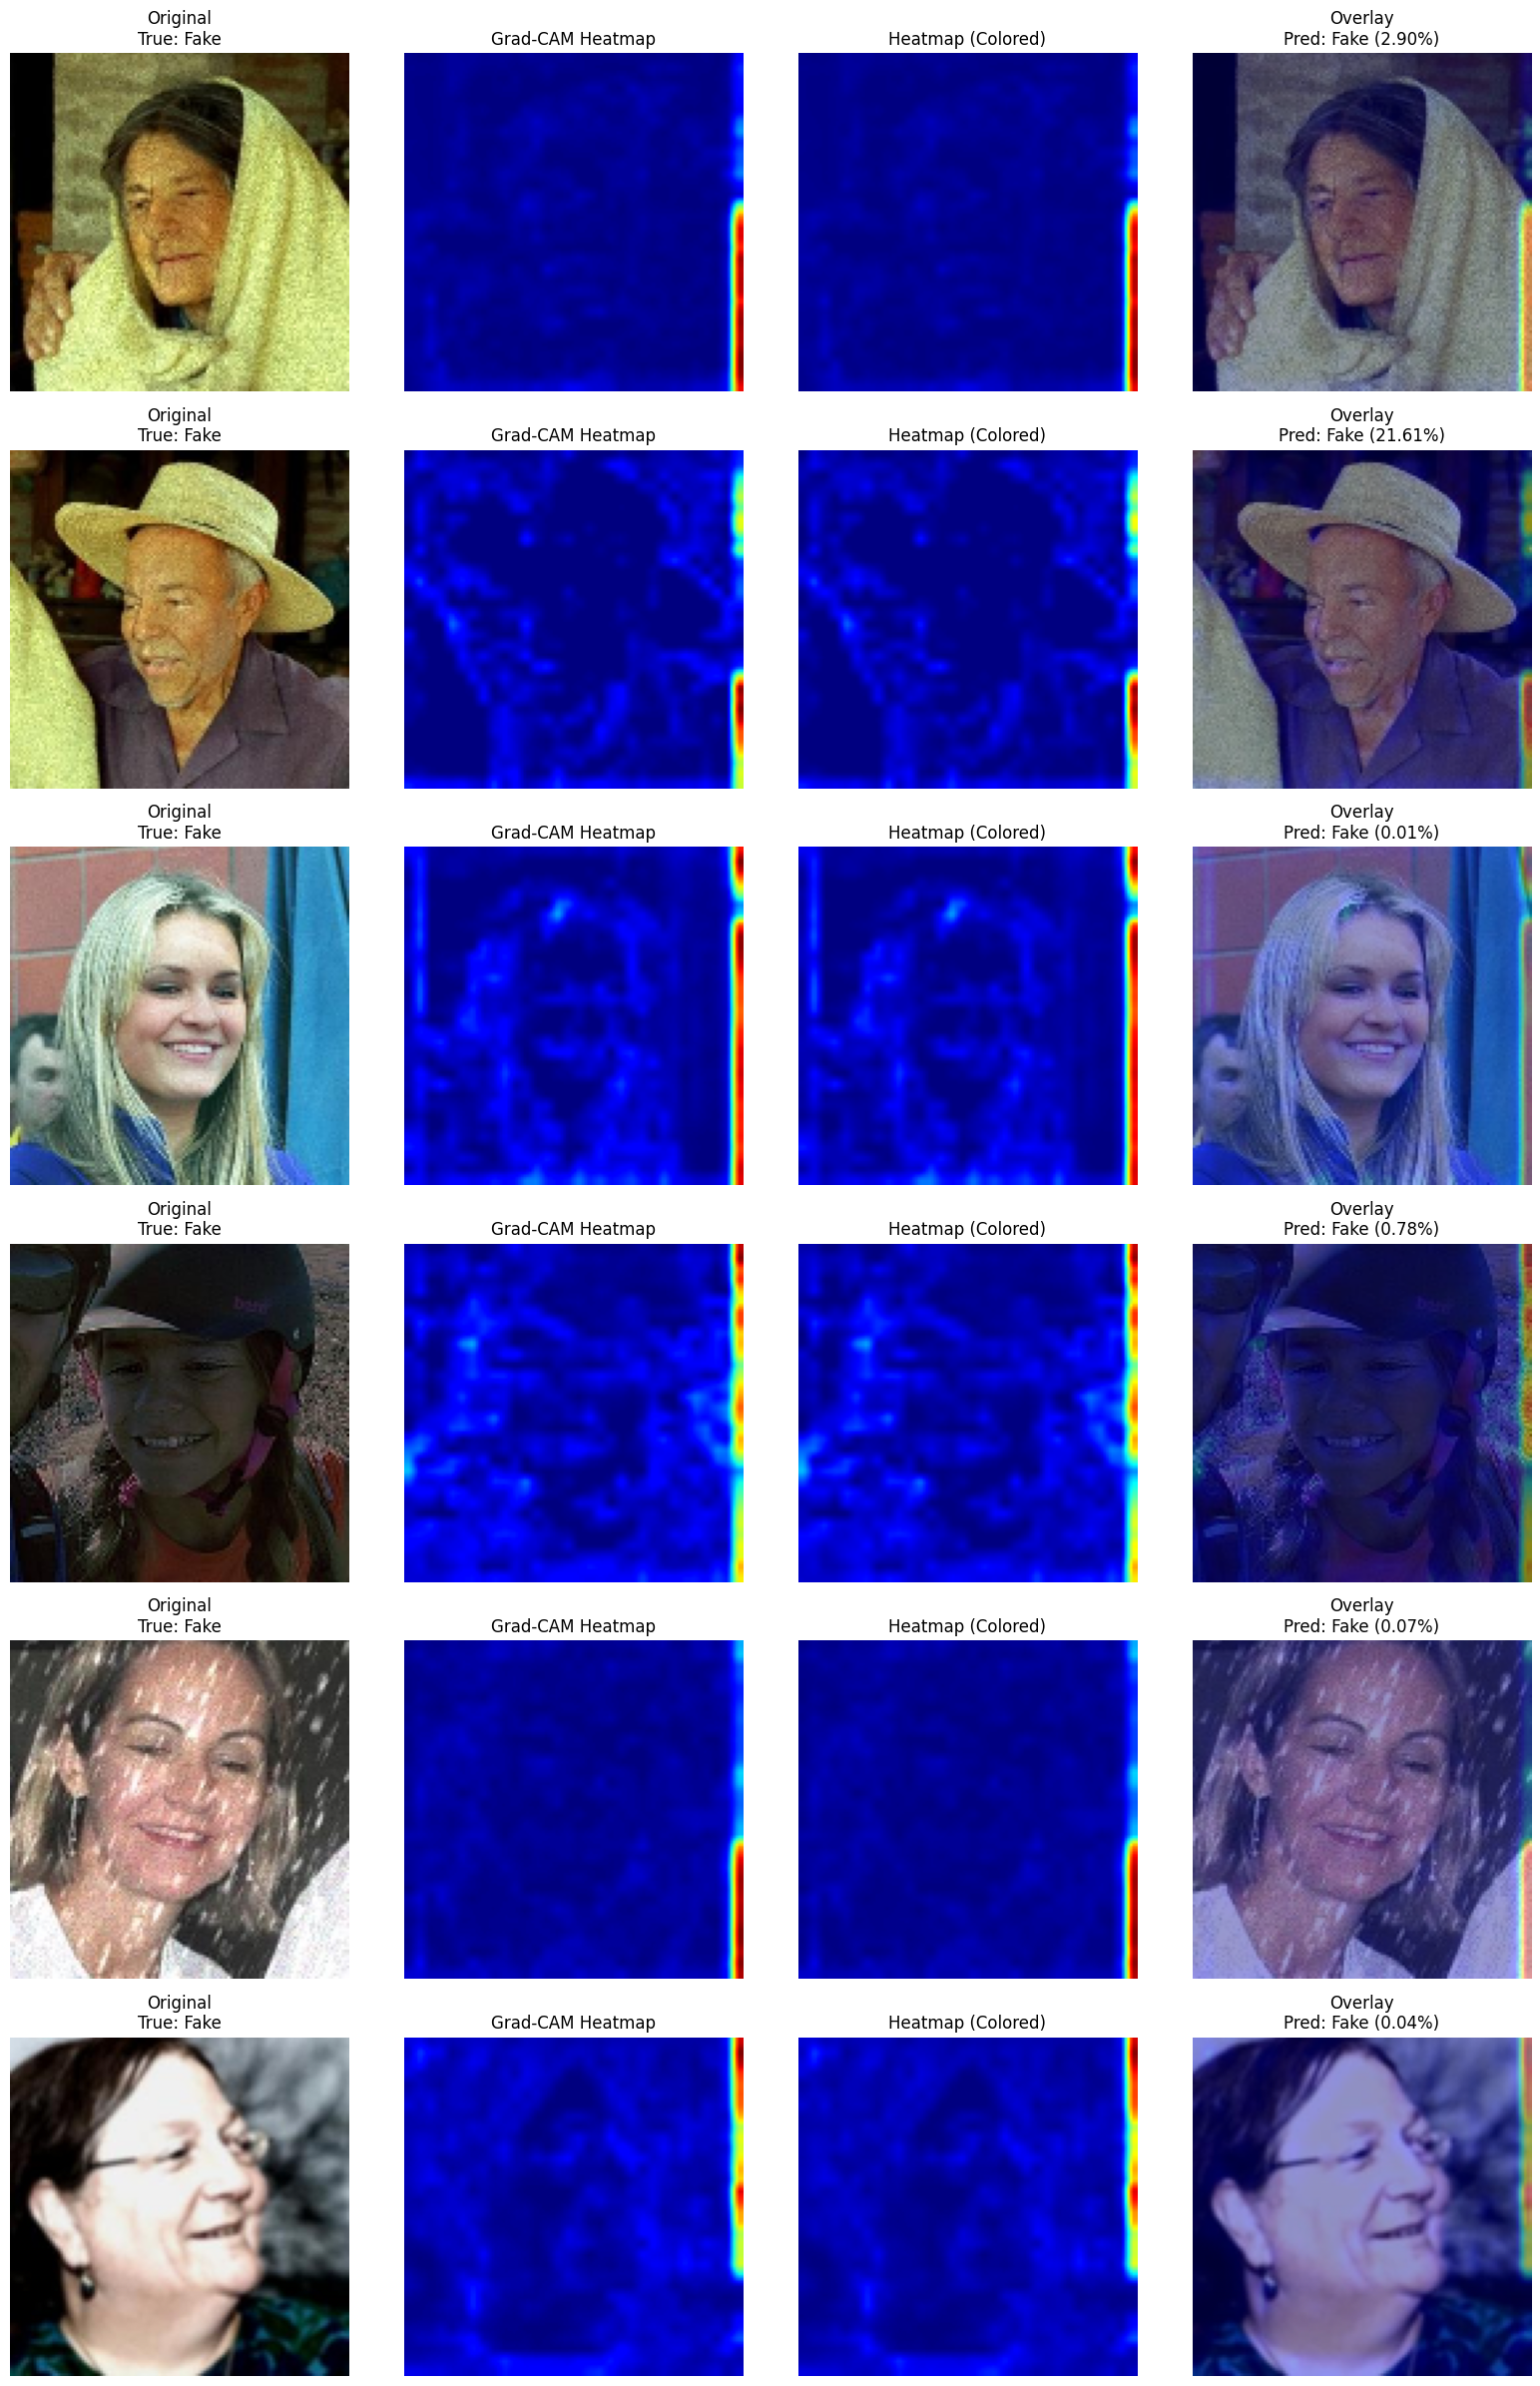

In [ ]:
def visualize_gradcam_samples(model, test_gen, num_samples=4):
   

    test_gen.reset()
    x_batch, y_batch = next(test_gen)

    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples*4))

    for i in range(min(num_samples, len(x_batch))):
        img = x_batch[i]
        true_label = "Real" if y_batch[i] == 1 else "Fake"

        # Predict
        img_array = np.expand_dims(img, 0)
        prediction = model.predict(img_array, verbose=0)[0][0]
        pred_label = "Real" if prediction > 0.5 else "Fake"

        # Generate Grad-CAM
        heatmap = generate_gradcam(model, img_array)
        overlayed, heatmap_colored = overlay_heatmap(img, heatmap)

        # Plot
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Original\nTrue: {true_label}")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(heatmap, cmap='jet')
        axes[i, 1].set_title("Grad-CAM Heatmap")
        axes[i, 1].axis('off')

        axes[i, 2].imshow(heatmap_colored)
        axes[i, 2].set_title("Heatmap (Colored)")
        axes[i, 2].axis('off')

        axes[i, 3].imshow(overlayed)
        axes[i, 3].set_title(f"Overlay\nPred: {pred_label} ({prediction:.2%})")
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(config.MODEL_DIR, 'gradcam_samples.png'), dpi=150)
    plt.show()

print("Generating Grad-CAM visualizations...")
visualize_gradcam_samples(model, test_gen, num_samples=6)

## 12. Error Analysis

341/341 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step

Total errors: 1583 / 10905 (14.52%)
False Positives (Fake→Real): 299
False Negatives (Real→Fake): 1284


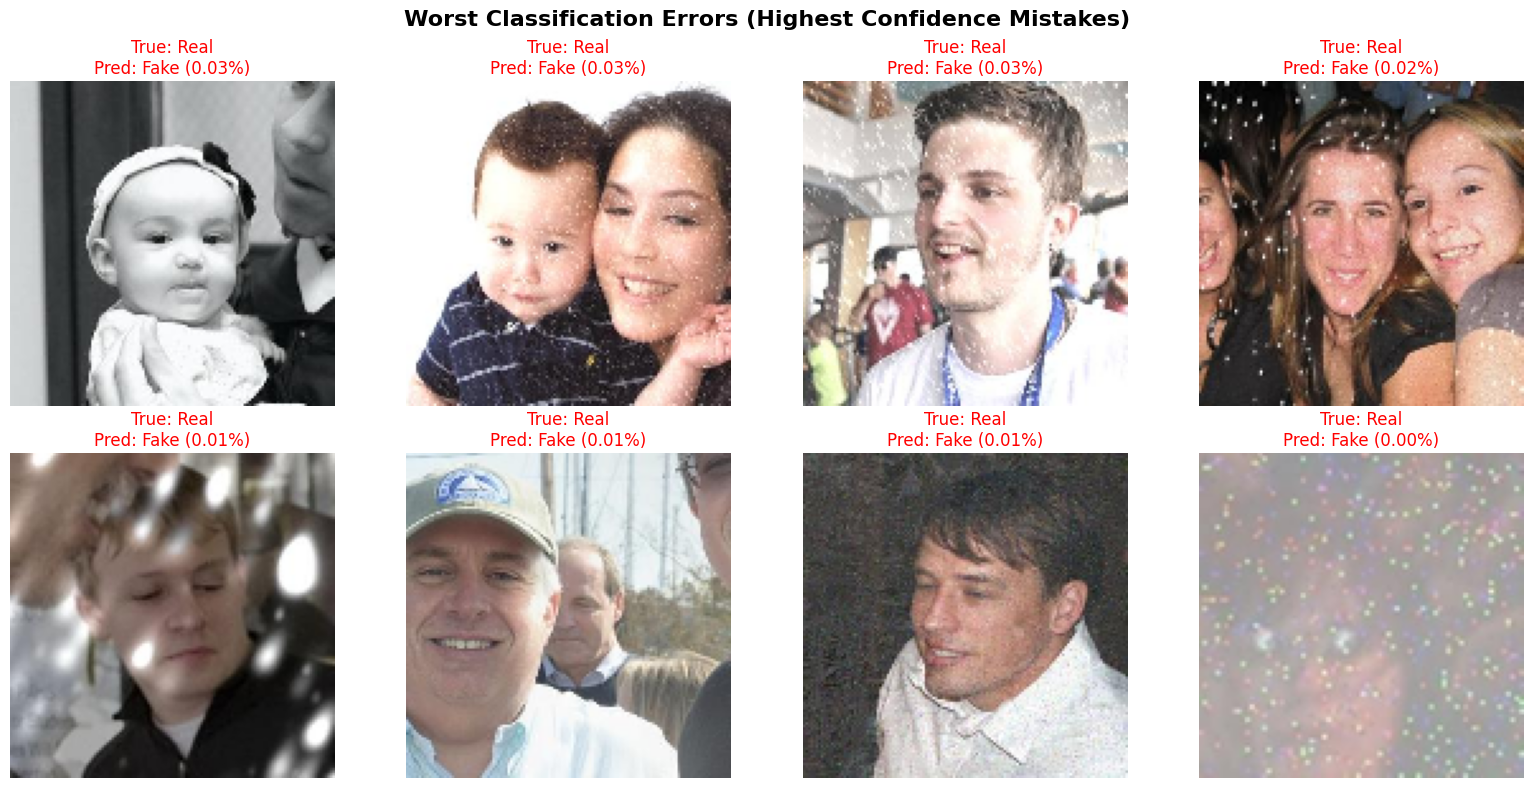

In [ ]:
def analyze_errors(model, test_gen, num_errors=8):
   

    # Get all predictions
    test_gen.reset()
    predictions = model.predict(test_gen, verbose=1)
    y_pred = (predictions > 0.5).astype(int).flatten()
    y_true = test_gen.classes[:len(predictions)]

    # Find errors
    errors_idx = np.where(y_pred != y_true)[0]
    print(f"\nTotal errors: {len(errors_idx)} / {len(y_true)} ({len(errors_idx)/len(y_true)*100:.2f}%)")

    # False positives (predicted Real, actually Fake)
    fp_idx = np.where((y_pred == 1) & (y_true == 0))[0]
    print(f"False Positives (Fake→Real): {len(fp_idx)}")

    # False negatives (predicted Fake, actually Real)
    fn_idx = np.where((y_pred == 0) & (y_true == 1))[0]
    print(f"False Negatives (Real→Fake): {len(fn_idx)}")

    # Visualize worst errors (highest confidence mistakes)
    if len(errors_idx) > 0:
        # Calculate confidence of errors
        error_confidences = np.abs(predictions[errors_idx].flatten() - 0.5)
        worst_errors_idx = errors_idx[np.argsort(error_confidences)[-num_errors:]]

        # Get images
        test_gen.reset()
        all_images = []
        for _ in range(len(test_gen)):
            x_batch, _ = next(test_gen)
            all_images.extend(x_batch)

      
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        axes = axes.ravel()

        for i, idx in enumerate(worst_errors_idx[:num_errors]):
            img = all_images[idx]
            true_label = config.CLASS_NAMES[y_true[idx]]
            pred_label = config.CLASS_NAMES[y_pred[idx]]
            confidence = predictions[idx][0]

            axes[i].imshow(img)
            axes[i].set_title(
                f"True: {true_label}\nPred: {pred_label} ({confidence:.2%})",
                color='red'
            )
            axes[i].axis('off')

        plt.suptitle('Worst Classification Errors (Highest Confidence Mistakes)',
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(config.MODEL_DIR, 'error_analysis.png'), dpi=150)
        plt.show()

analyze_errors(model, test_gen)

## 13. Save Results Summary

In [54]:
import json

# Prepare results summary
results_summary = {
    'model_name': 'DeepfakeDetector_Enhanced',
    'timestamp': config.TIMESTAMP,
    'architecture': {
        'total_params': int(model.count_params()),
        'input_shape': config.IMG_SHAPE,
        'features': ['Residual Blocks', 'Channel Attention', 'Batch Normalization']
    },
    'training': {
        'epochs_trained': len(history.history['loss']),
        'batch_size': config.BATCH_SIZE,
        'initial_lr': config.INITIAL_LR,
        'train_samples': train_gen.samples,
        'val_samples': val_gen.samples,
        'test_samples': test_gen.samples
    },
    'test_metrics': {
        'accuracy': float(eval_results['metrics']['accuracy']),
        'precision': float(eval_results['metrics']['precision']),
        'recall': float(eval_results['metrics']['recall']),
        'auc': float(eval_results['metrics']['auc']),
        'roc_auc': float(eval_results['roc_auc']),
        'avg_precision': float(eval_results['avg_precision'])
    },
    'confusion_matrix': eval_results['confusion_matrix'].tolist()
}

# Save to JSON
results_file = os.path.join(config.MODEL_DIR, 'results_summary.json')
with open(results_file, 'w') as f:
    json.dump(results_summary, f, indent=4)

print(f"Results summary saved to: {results_file}")
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(json.dumps(results_summary['test_metrics'], indent=2))

Results summary saved to: /content/deep-fake-detection/models_20260216_221819/results_summary.json

FINAL RESULTS SUMMARY
{
  "accuracy": 0.8548372387886047,
  "precision": 0.9324751496315002,
  "recall": 0.7627933025360107,
  "auc": 0.9451855421066284,
  "roc_auc": 0.9486879055829691,
  "avg_precision": 0.9515093162104225
}


## 14. Inference Functions for Production

In [ ]:
class DeepfakeDetector:
   

    def __init__(self, model_path):
        self.model = keras.models.load_model(model_path)
        self.face_detector = FaceDetector()
        print(f"Model loaded from: {model_path}")

    def preprocess_image(self, img_path):
        """Preprocess image with face detection"""
        return self.face_detector.detect_and_extract_face(img_path)

    def predict(self, img_path, return_gradcam=False):
        
        # Preprocess
        img = self.preprocess_image(img_path)
        if img is None:
            return {'error': 'Could not load image'}

        img_array = np.expand_dims(img, 0)

        # Predict
        prediction = self.model.predict(img_array, verbose=0)[0][0]

        result = {
            'prediction': 'Real' if prediction > 0.5 else 'Fake',
            'confidence': float(prediction if prediction > 0.5 else 1 - prediction),
            'probability': {
                'real': float(prediction),
                'fake': float(1 - prediction)
            }
        }

        # Generate Grad-CAM if requested
        if return_gradcam:
            heatmap = generate_gradcam(self.model, img_array)
            overlayed, _ = overlay_heatmap(img, heatmap)
            result['gradcam'] = overlayed
            result['original_image'] = (img * 255).astype(np.uint8)

        return result

    def visualize_prediction(self, img_path):
        """
        Visualize prediction with Grad-CAM
        """
        result = self.predict(img_path, return_gradcam=True)

        if 'error' in result:
            print(result['error'])
            return

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        ax1.imshow(result['original_image'])
        ax1.set_title('Original Image')
        ax1.axis('off')

        ax2.imshow(result['gradcam'])
        title = f"Prediction: {result['prediction']}\nConfidence: {result['confidence']:.2%}"
        ax2.set_title(title)
        ax2.axis('off')

        plt.tight_layout()
        plt.show()

        print(f"\nPrediction: {result['prediction']}")
        print(f"Confidence: {result['confidence']:.2%}")
        print(f"Probabilities:")
        print(f"  Real: {result['probability']['real']:.2%}")
        print(f"  Fake: {result['probability']['fake']:.2%}")

# Initialize detector
detector = DeepfakeDetector(config.BEST_MODEL_PATH)
print("\nDeepfake detector ready for inference!")

Model loaded from: /content/deep-fake-detection/models_20260216_221819/best_model.keras

Deepfake detector ready for inference!


### Test Inference on Sample Images

Testing on REAL image:
Using layer: conv2d_9


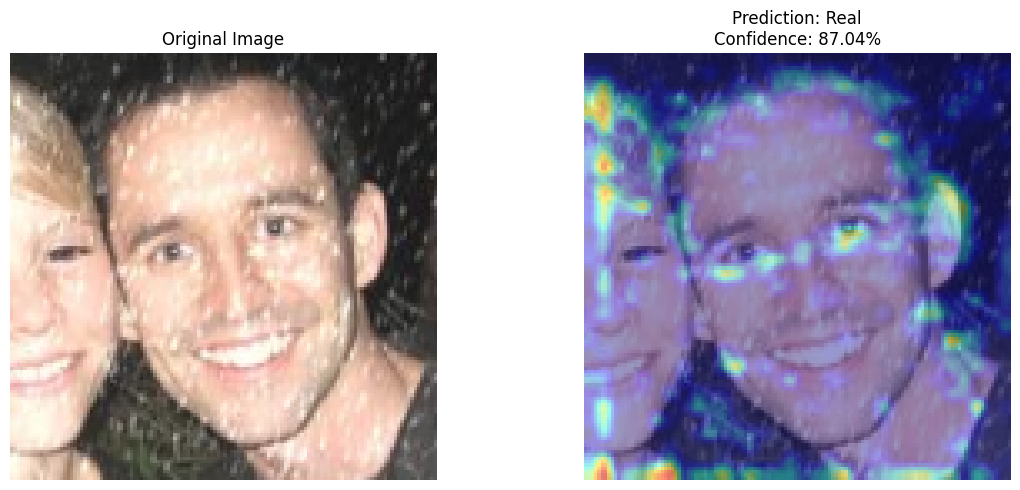


Prediction: Real
Confidence: 87.04%
Probabilities:
  Real: 87.04%
  Fake: 12.96%


Testing on FAKE image:
Using layer: conv2d_9


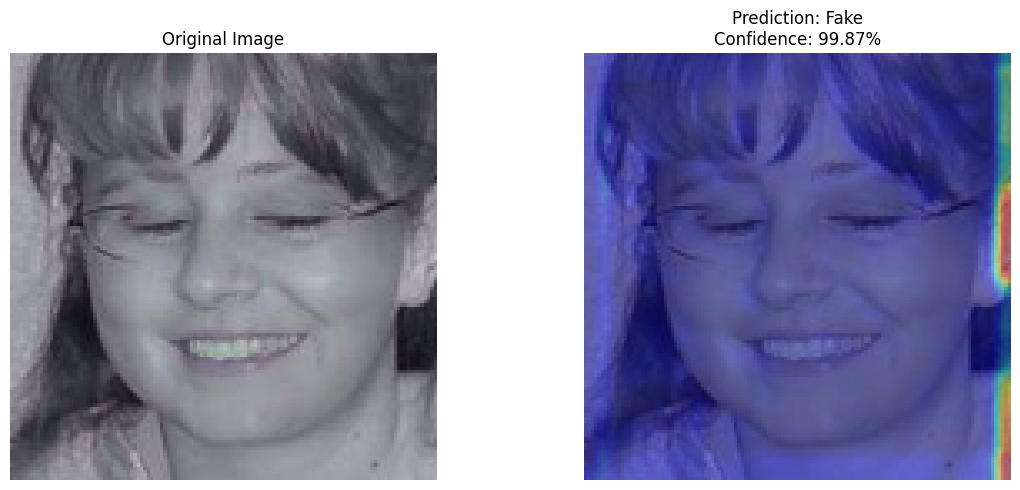


Prediction: Fake
Confidence: 99.87%
Probabilities:
  Real: 0.13%
  Fake: 99.87%


In [ ]:

test_real = os.path.join(config.TEST_DIR, "Real")
test_fake = os.path.join(config.TEST_DIR, "Fake")

if os.path.exists(test_real) and os.path.exists(test_fake):
    # Test on real image
    real_img = os.path.join(test_real, os.listdir(test_real)[2])
    print("Testing on REAL image:")
    print("=" * 60)
    detector.visualize_prediction(real_img)

    print("\n" + "=" * 60)

    # Test on fake image
    fake_img = os.path.join(test_fake, os.listdir(test_fake)[0])
    print("\nTesting on FAKE image:")
    print("=" * 60)
    detector.visualize_prediction(fake_img)

## 15. Conclusion 

### What we've accomplished:
1.  Face detection preprocessing
2.  Enhanced CNN with attention mechanisms
3.  Comprehensive evaluation metrics
4.  Grad-CAM visualization for explainability
5.  Error analysis
6.  Production-ready inference pipeline



**Model saved in:** `{config.MODEL_DIR}`  
**All visualizations saved in:** `{config.MODEL_DIR}`  
**Results summary:** `{config.MODEL_DIR}/results_summary.json`

In [ ]:
!ls /content/

deep-fake-detection  drive  sample_data


In [58]:
!cp -r /content/DeepfakeProject/Dataset/models_20260208_162615/ /content/drive/MyDrive/DeepfakeProject/output/

cp: cannot stat '/content/DeepfakeProject/Dataset/models_20260208_162615/': No such file or directory


In [ ]:
!ls /content/drive/MyDrive/DeepfakeProject/output/

In [ ]:
!mkdir -p /content/drive/MyDrive/DeepfakeProject/output

In [ ]:
print("\n" + "="*60)
print("MODEL VERIFICATION")
print("="*60)

import os
if os.path.exists(config.MODEL_PATH):
    size_mb = os.path.getsize(config.MODEL_PATH) / 1024 / 1024
    print(f" Model saved: {config.MODEL_PATH}")
    print(f"   Size: {size_mb:.2f} MB")
else:
    print(f" Model file not found!")

print("\nTesting model loading...")
try:
    test_load = tf.keras.models.load_model(config.MODEL_PATH)
    print(" Model loads successfully in Colab")
    print(f"   Input shape: {test_load.input_shape}")
    print(f"   Output shape: {test_load.output_shape}")
    print(f"   Parameters: {test_load.count_params():,}")
except Exception as e:
    print(f" Error loading model: {e}")

print("="*60)


MODEL VERIFICATION
✅ Model saved: /content/deep-fake-detection/models_20260216_221819/deepfake_enhanced_model.keras
   Size: 17.34 MB

Testing model loading...
✅ Model loads successfully in Colab
   Input shape: (None, 128, 128, 3)
   Output shape: (None, 1)
   Parameters: 1,497,145


In [66]:
ls /content/deep-fake-detection/models_20260216_221819/

best_model.keras               error_analysis.png      results_summary.json
confusion_matrix.png           gradcam_samples.png     roc_pr_curves.png
deepfake_enhanced_model.h5     logs/                   sample_images.png
deepfake_enhanced_model.keras  model_architecture.png  training_history.png


In [ ]:
!zip -r .zip /content/deep-fake-detection/models_20260216_221819/

  adding: content/deep-fake-detection/models_20260216_221819/ (stored 0%)
  adding: content/deep-fake-detection/models_20260216_221819/error_analysis.png (deflated 6%)
  adding: content/deep-fake-detection/models_20260216_221819/sample_images.png (deflated 6%)
  adding: content/deep-fake-detection/models_20260216_221819/confusion_matrix.png (deflated 20%)
  adding: content/deep-fake-detection/models_20260216_221819/roc_pr_curves.png (deflated 16%)
  adding: content/deep-fake-detection/models_20260216_221819/logs/ (stored 0%)
  adding: content/deep-fake-detection/models_20260216_221819/logs/train/ (stored 0%)
  adding: content/deep-fake-detection/models_20260216_221819/logs/train/events.out.tfevents.1771280321.99e95dbf10b0.921.0.v2 (deflated 65%)
  adding: content/deep-fake-detection/models_20260216_221819/logs/validation/ (stored 0%)
  adding: content/deep-fake-detection/models_20260216_221819/logs/validation/events.out.tfevents.1771281339.99e95dbf10b0.921.1.v2 (deflated 76%)
  adding:

In [ ]:
from google.colab import files
files.download("archive_name.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>